### 1. Data Loading & Preprocessing 

In [12]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("varunraskar/cancer-regression")

print("Path to dataset files:", path)

Path to dataset files: /Users/adaeyja/.cache/kagglehub/datasets/varunraskar/cancer-regression/versions/1


In [13]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("varunraskar/cancer-regression")

df1 = pd.read_csv(f"{path}/cancer_reg.csv")
df2 = pd.read_csv(f"{path}/avg-household-size.csv")

print("cancer_reg columns:", df1.columns.tolist())
print("avg-household-size columns:", df2.columns.tolist())
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

cancer_reg columns: ['avganncount', 'avgdeathsperyear', 'target_deathrate', 'incidencerate', 'medincome', 'popest2015', 'povertypercent', 'studypercap', 'binnedinc', 'medianage', 'medianagemale', 'medianagefemale', 'geography', 'percentmarried', 'pctnohs18_24', 'pcths18_24', 'pctsomecol18_24', 'pctbachdeg18_24', 'pcths25_over', 'pctbachdeg25_over', 'pctemployed16_over', 'pctunemployed16_over', 'pctprivatecoverage', 'pctprivatecoveragealone', 'pctempprivcoverage', 'pctpubliccoverage', 'pctpubliccoveragealone', 'pctwhite', 'pctblack', 'pctasian', 'pctotherrace', 'pctmarriedhouseholds', 'birthrate']
avg-household-size columns: ['statefips', 'countyfips', 'avghouseholdsize', 'geography']
df1 shape: (3047, 33)
df2 shape: (3220, 4)


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import kagglehub

path = kagglehub.dataset_download("varunraskar/cancer-regression") 

df = pd.read_csv(f"{path}/cancer_reg.csv")

df = df.dropna(subset=['target_deathrate'])
df = df.fillna(df.median(numeric_only=True))

for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].str.contains('\(.*\]').any():
            df[col] = df[col].str.extract('\((.*?),').astype(float)
        else:
            df[col] = df[col].astype('category').cat.codes

df = df.select_dtypes(include=[np.number])

X = df.drop(columns=['target_deathrate'])
y = df['target_deathrate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 2. Exploratory Data Analysis (EDA) 

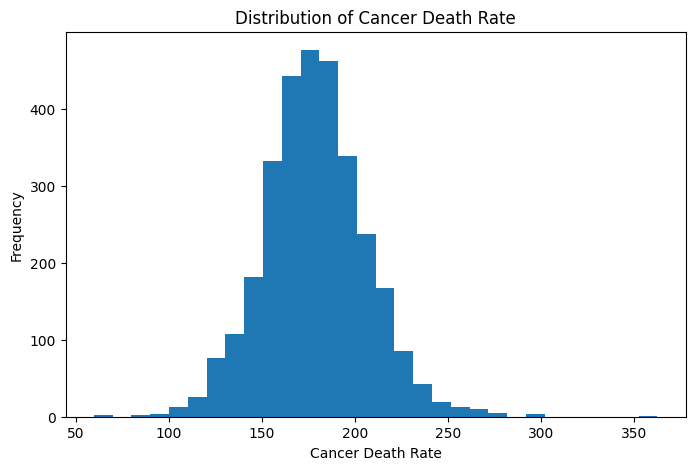

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Cancer Death Rate
plt.figure(figsize=(8,5))
plt.hist(df['target_deathrate'], bins=30)
plt.title('Distribution of Cancer Death Rate')
plt.xlabel('Cancer Death Rate')
plt.ylabel('Frequency')
plt.show()

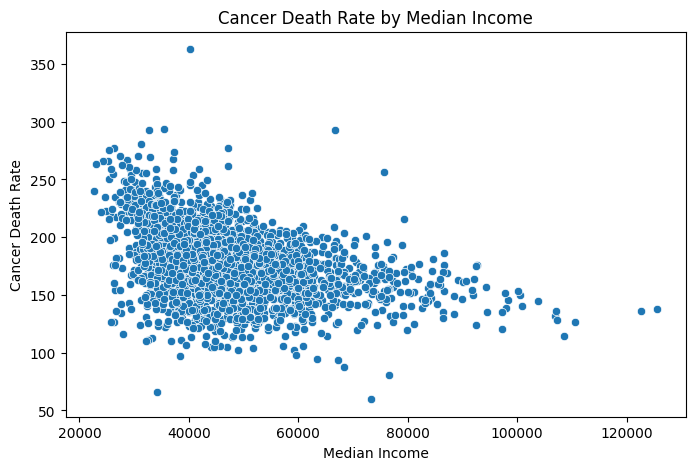

In [16]:
# Cancer Death Rate by Median Income
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='medincome', y='target_deathrate')
plt.title('Cancer Death Rate by Median Income')
plt.xlabel('Median Income')
plt.ylabel('Cancer Death Rate')
plt.show()

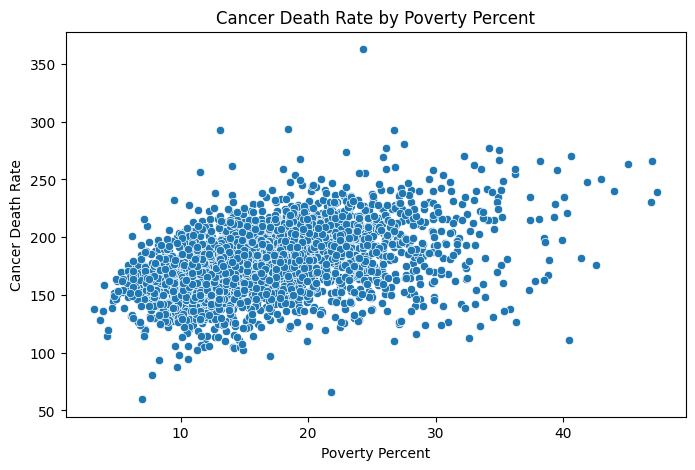

In [48]:
# Cancer Death Rate by Poverty Percent
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='povertypercent', y='target_deathrate')
plt.title('Cancer Death Rate by Poverty Percent')
plt.xlabel('Poverty Percent')
plt.ylabel('Cancer Death Rate')
plt.show()

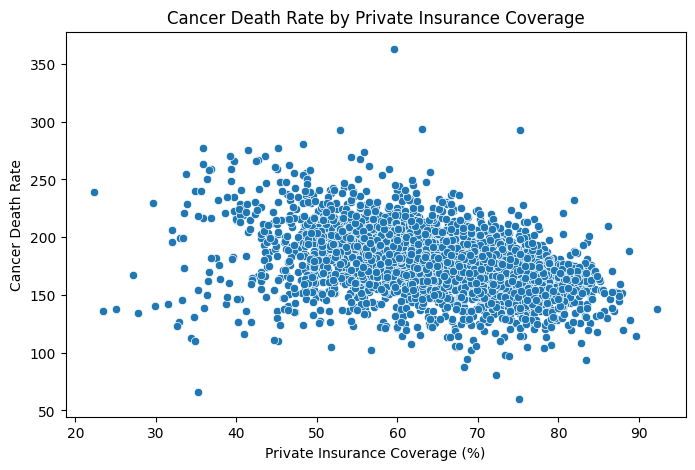

In [49]:
# Cancer Death Rate by Private Insurance Coverage
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='pctprivatecoverage', y='target_deathrate')
plt.title('Cancer Death Rate by Private Insurance Coverage')
plt.xlabel('Private Insurance Coverage (%)')
plt.ylabel('Cancer Death Rate')
plt.show()

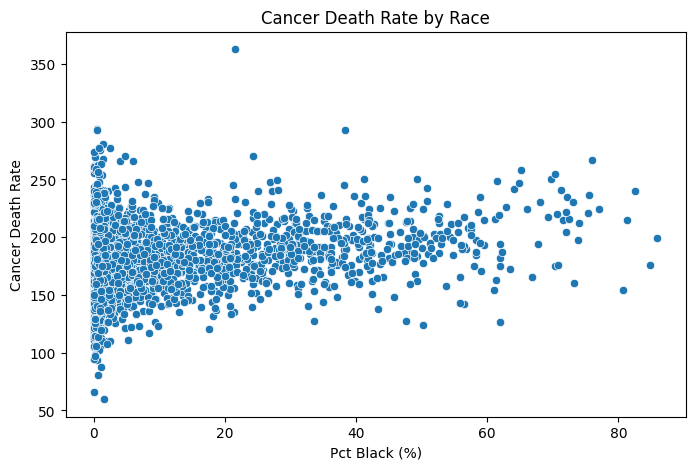

In [50]:
# Cancer Death Rate by Race
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='pctblack', y='target_deathrate')
plt.title('Cancer Death Rate by Race')
plt.xlabel('Pct Black (%)')
plt.ylabel('Cancer Death Rate')
plt.show()

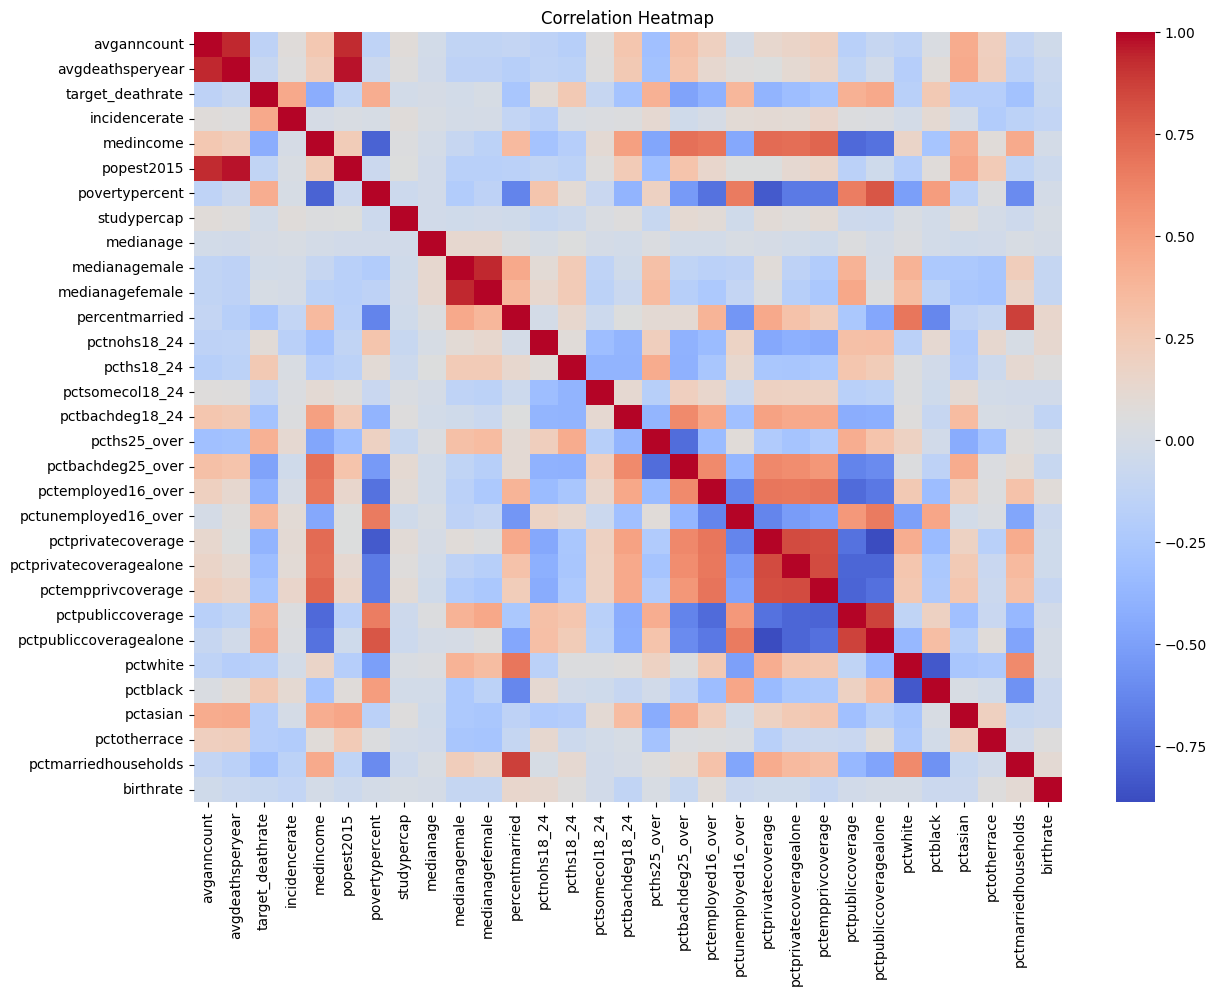

In [51]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 3. Model Design & Implementation 

Mean Squared Error: 396.02
R^2 Score: 0.52


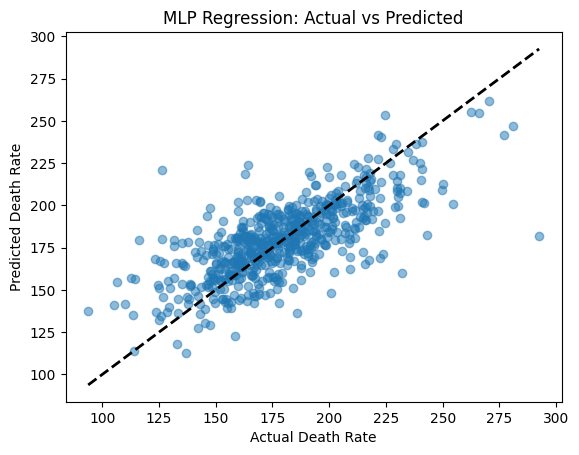

In [17]:
# Model Design & Implementation
# MLP Neural Network - 3 hidden layers
# Hidden Layer 1: 100 neurons, ReLU activation
# Hidden Layer 2: 50 neurons, ReLU activation
# Hidden Layer 3: 25 neurons, ReLU activation
# Optimizer: Adam | Loss Function: MSE | Max Iterations: 2000

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Death Rate')
plt.ylabel('Predicted Death Rate')
plt.title('MLP Regression: Actual vs Predicted')
plt.show()

### 4. Model Evaluations & Visualizations 

In [42]:
from sklearn.metrics import mean_absolute_error
import numpy as np

#  Extended Evaluation Metrics 
# MAE: Average absolute difference between predicted and actual death rates
# RMSE: Square root of MSE, penalizes larger errors more heavily 
# R^2: Measures how well our model explains variance in cancer death rates (1.0 = perfect)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 14.81
Root Mean Squared Error (RMSE): 19.90
R^2 Score: 0.52


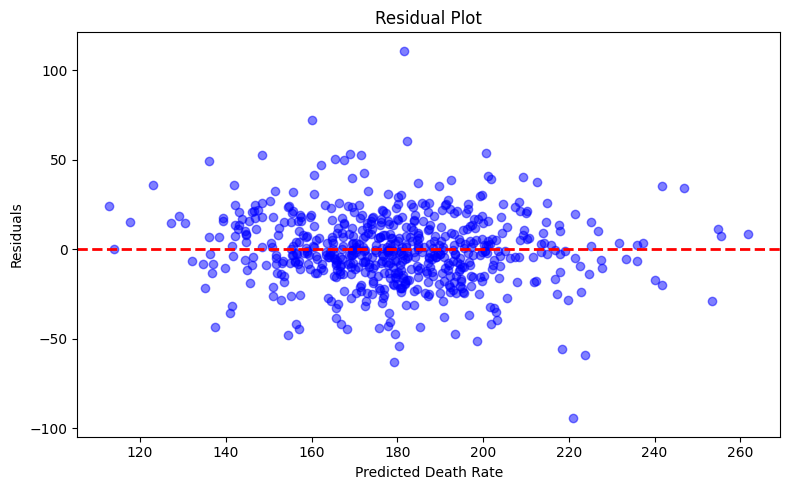

In [18]:
# Residual Plot 
# Residuals show the difference between actual and predicted values 
# Points close to the red line = more accurate predictions

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Death Rate')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

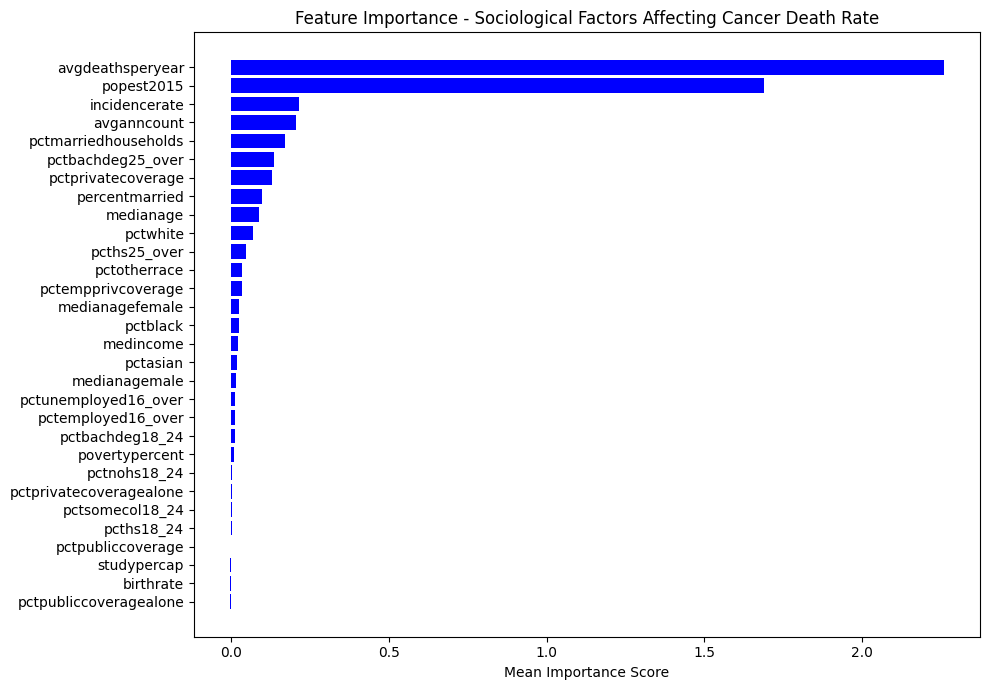

In [44]:
# Feature Importance (Permutation Based)
# Shows which sociological factors most influence cancer death rates 

from sklearn.inspection import permutation_importance

result = permutation_importance(mlp, X_test_scaled, y_test, n_repeats=10, random_state=42)
feature_names = X.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.xlabel('Mean Importance Score')
plt.title('Feature Importance - Sociological Factors Affecting Cancer Death Rate')
plt.tight_layout()
plt.show()

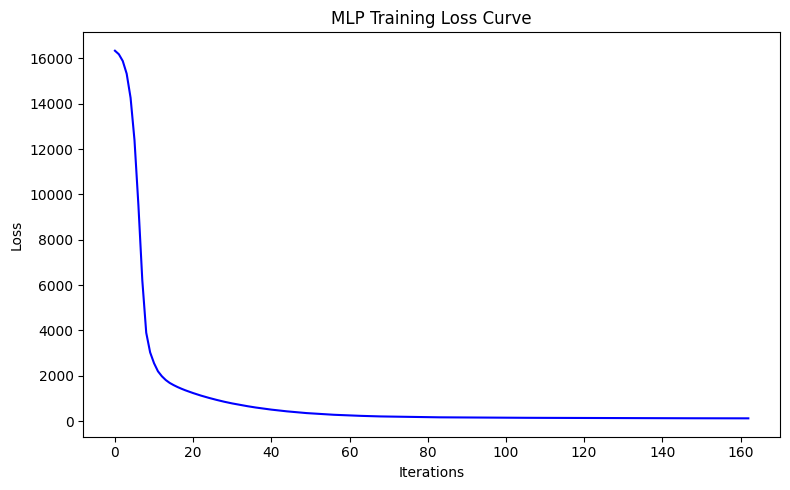

In [45]:
# Training Loss Curve 
# Shows how the model's error decreased over each training iteration 

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='blue')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.tight_layout()
plt.show()

In [5]:
print("Number of input features:", X.shape[1])

Number of input features: 30


In [19]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

R² Score: 0.52
Mean Squared Error (MSE): 396.02
Root Mean Squared Error (RMSE): 19.90
Mean Absolute Error (MAE): 14.81
